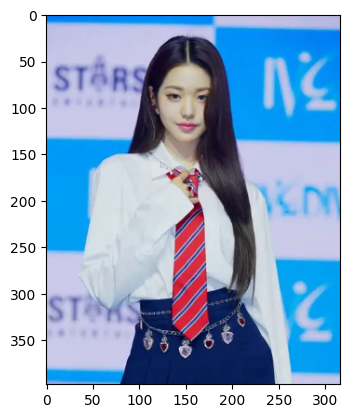

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

path = '/content/idol_girl.png'

img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [2]:
# 기본 정보 파악 (가로, 세로)
img.shape

(398, 317, 3)

In [4]:
height, width = img.shape[:2]

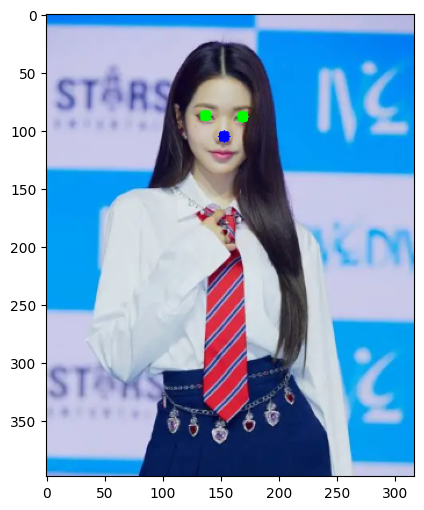

In [55]:
eye_left_x, eye_left_y = int(width*0.435), int(height * 0.220)
eye_right_x, eye_right_y = int(width * 0.535), int(height*0.222)
nose_x, nose_y = int(width*0.485), int(height*0.265)

# 원본 이미지 위에 좌표를 찍어서 확인

marked_img = img.copy()

cv2.circle(marked_img, (eye_left_x, eye_left_y),5 , (0, 255, 0),-1) # cv2.imread니까 BGR
cv2.circle(marked_img, (eye_right_x, eye_right_y),5 , (0, 255, 0),-1)
cv2.circle(marked_img, (nose_x, nose_y),5 , (0, 0, 255),-1)

plt.figure(figsize=(6,6))
# plt.imshow(cv2.cvtColor(marked_img,cv2.COLOR_BGR2RGB))
plt.imshow(marked_img)
plt.show()


In [33]:
def plastic_filter(img, center_x, center_y, radius, strength):
    h,w = img.shape[:2]

    # 1. 원본 이미지  크기와 1:1로 매치오디는 빈 좌표 지도 map생성
    # map_y, map_x = h,w 이거 안되남? 튜플이라 못바꿔서 문제가 되나?
    map_y, map_x = np.indices((h,w),dtype=np.float32) # indices 그 위치에 저장된건 그위치의 위치좌표다.
                                                    # 원래 for문을 써야 하는데 이걸 쓰면 더 빠르다.
    # 자주쓰니까 걍 외우면 될듯

    # 2. 지정된 중심점으로 부터 모든 픽셀까지 거리 구하기.
    delta_x = map_x - center_x
    delta_y = map_y - center_y

    distance = np.sqrt(delta_x**2 + delta_y**2)

    # 3. 지정한 반지름 안에 들어오는 픽셀들만 골라내는 마스크 생성

    mask = (distance < radius)

    # 4. 수학적 왜곡 공식 적용
    # 여기서 적용할 공식은
    # 거리를 반지름 비율로 나눈 뒤, strength 제곱을 해서 픽셀을 밀거나 당길 강도를 정함
    # strength는 미리 정해진 상수값이기 때문에 거리에 비례해서 왜곡 정도가 달라짐.

    factor = (distance/radius) ** strength

    # distance의 최댓값이 radius기 때문에 factor는 [0,1]의 값을 갖는다
    # factor == 1 은 왜곡 0%라는 의미다.


    # 이동할 좌표 = 중심점 + (원래 거리 * factor)
    # new_x = center_x +(delta_x * factor)
    # new_y = center_y +(delta_y * factor)
    # 즉, factor가 작다 == 원래 거리가 매우 작아진다. == 중심점에 가까워진다.
    # 이건 오목렌즈

    # 왜곡 공식을 이동할 좌표 = 중심점 + (원래 거리 / factor)로 하면 볼록렌즈


    # 5. 좌표 변형  -  마스크 영역 내부에 픽셀 좌표 지도 조작
    map_x[mask] = center_x + delta_x[mask] * factor[mask] # mask 가 boolean형식이니까 이건 불리언 인덱
    # 변형 후 좌표
    map_y[mask] = center_y + delta_y[mask] * factor[mask]



    return cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR,borderMode = cv2.BORDER_REFLECT)
    # BORDER_REFLECT -> 테두리는 반사돼서 깨짐 방지


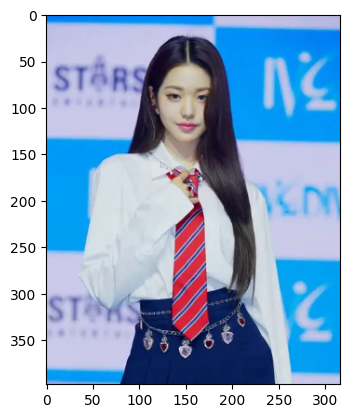

In [49]:
# img에 안변했는지 확인
plt.imshow(img)
plt.show()

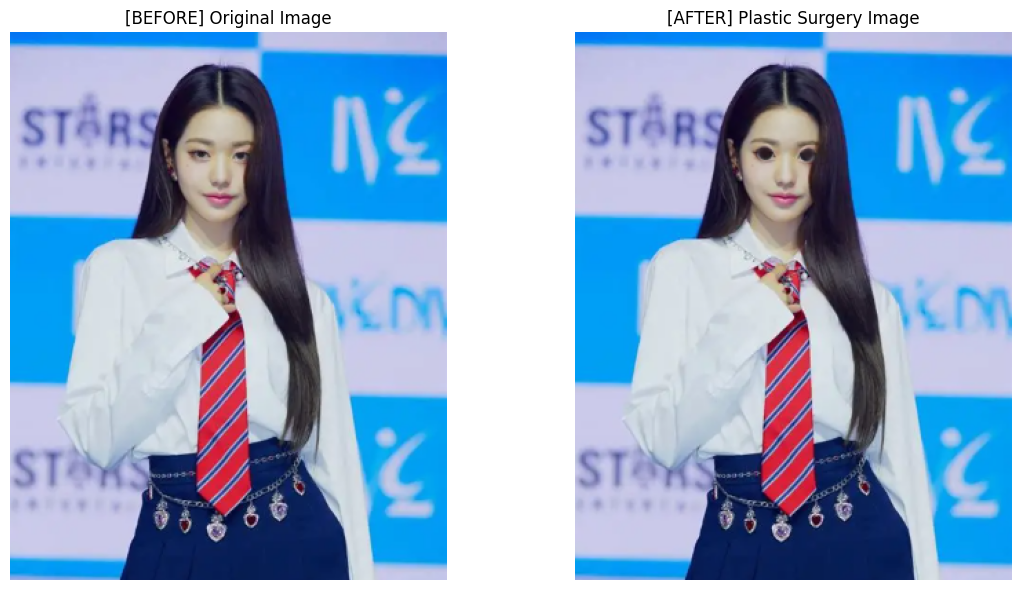

In [58]:
# 단계 1 : 왼쪽 눈 확대 (strength > 1 이면 확대 , strenth < 1이면 축소)
step1 = plastic_filter(img, center_x = eye_left_x, center_y = eye_left_y,radius = 7,strength = 1.8)
# 단계 2 : 오른쪽 눈 확대
step2 = plastic_filter(step1, center_x = eye_right_x, center_y = eye_right_y,radius = 7,strength = 1.8)

# 단계 3 : 코 축소
step3 = plastic_filter(step2, center_x = nose_x, center_y = nose_y,radius = 5,strength = 0.5)

# original_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# plastic_rgb = cv2.cvtColor(step3, cv2.COLOR_BGR2RGB)

original_rgb  = img
plastic_rgb = step3

plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.imshow(original_rgb)
plt.title("[BEFORE] Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(plastic_rgb)
plt.title("[AFTER] Plastic Surgery Image")
plt.axis('off')

plt.tight_layout()
plt.show()

# 강사님꺼는 색이 이상한데 처음에 불러올때 이미 rgb화를 해서
# rgb를 두번하니까 brg -> rgb -> gbr이 되어버림.

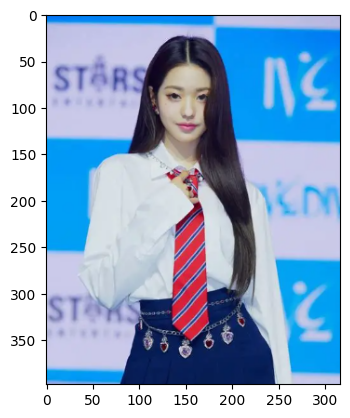

In [51]:
strength = 1.8

img1 = plastic_filter(img, eye_left_x, eye_left_y, 3, strength)
img2 = plastic_filter(img1, eye_right_x, eye_right_y, 3, strength)
img3 = plastic_filter(img2, nose_x, nose_y, 5, strength)

# 해봤는데 존나 징그러워서 주석처리해놨음/


plt.imshow(img3)
plt.show()
